In [ ]:
# =========================================
# 🧱 SETUP CELL — RUN THIS FIRST
# =========================================

import os

# -----------------------------
# 1. Check GPU
# -----------------------------
print("🔍 Checking GPU...")
!nvidia-smi || echo "⚠ No GPU detected"

# -----------------------------
# 2. Create required directories
# -----------------------------
print("\n📁 Creating project folders...")

folders = [
    "data",
    "data/celeba_subset",
    "scripts",
    "results",
    "results/mini_dcgan",
    "figures"
]

for f in folders:
    os.makedirs(f, exist_ok=True)
    print("✔ Created:", f)

# -----------------------------
# 3. Install required packages
# -----------------------------
print("\n📦 Installing required packages...")
!pip install torch torchvision matplotlib numpy scikit-learn pillow tqdm --quiet

print("\n✅ Setup complete. You can proceed to the next cell.")


🔍 Checking GPU...
/bin/bash: line 1: nvidia-smi: command not found
⚠ No GPU detected

📁 Creating project folders...
✔ Created: data
✔ Created: data/celeba_subset
✔ Created: scripts
✔ Created: results
✔ Created: results/mini_dcgan
✔ Created: figures

📦 Installing required packages...

✅ Setup complete. You can proceed to the next cell.


In [ ]:
# Upload kaggle.json first
import os
from google.colab import files
files.upload()

# Move to correct location
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download CelebA subset (small version)
!kaggle datasets download -d jessicali9530/celeba-dataset -p data
!unzip -q data/celeba-dataset.zip -d data/celeba_subset


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
 99% 1.32G/1.33G [00:10<00:00, 247MB/s]
100% 1.33G/1.33G [00:12<00:00, 114MB/s]


In [ ]:
!pwd

/content


In [ ]:
!unzip -q data/celeba-dataset.zip -d data/celeba_full


In [ ]:
import os, shutil
from glob import glob

src = "data/celeba_full/img_align_celeba/img_align_celeba"
dst = "data/celeba_subset"

os.makedirs(dst, exist_ok=True)

images = sorted(glob(os.path.join(src, "*.jpg")))[:10000]

for img in images:
    shutil.copy(img, dst)

print(f"✅ Copied {len(images)} images to {dst}")


✅ Copied 10000 images to data/celeba_subset


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import utils, transforms
from torch.utils.data import DataLoader
from PIL import Image
import glob, os, time

# --- Hyperparameters
nz = 64
ngf = 32
ndf = 32
epochs = 10
batch_size = 64

# --- Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Models
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x).view(-1)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optG = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

# --- Data
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

image_paths = glob.glob("data/celeba_subset/*.jpg")
dataset = [transform(Image.open(p).convert("RGB")) for p in image_paths]
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(f"Loaded {len(dataset)} images.")

# --- Training loop
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
os.makedirs("results/mini_dcgan", exist_ok=True)

for epoch in range(1, epochs+1):
    start = time.time()
    for real in loader:
        real = real.to(device)
        b = real.size(0)

        # --- Train D
        D.zero_grad()
        lbl_real = torch.ones(b, device=device)
        lbl_fake = torch.zeros(b, device=device)

        out_real = D(real)
        loss_real = criterion(out_real, lbl_real)

        noise = torch.randn(b, nz, 1, 1, device=device)
        fake = G(noise)
        out_fake = D(fake.detach())
        loss_fake = criterion(out_fake, lbl_fake)

        lossD = loss_real + loss_fake
        lossD.backward()
        optD.step()

        # --- Train G
        G.zero_grad()
        output = D(fake)
        lossG = criterion(output, lbl_real)
        lossG.backward()
        optG.step()

    # --- Save progress
    print(f"Epoch {epoch}/{epochs} | D Loss: {lossD.item():.4f} | G Loss: {lossG.item():.4f} | Time: {time.time()-start:.2f}s")
    with torch.no_grad():
        samples = (G(fixed_noise).cpu() * 0.5 + 0.5)
        utils.save_image(samples, f"results/mini_dcgan/samples_epoch_{epoch}.png")

# --- Save models
torch.save(G.state_dict(), "results/mini_dcgan/G.pth")
torch.save(D.state_dict(), "results/mini_dcgan/D.pth")
print("✅ Training complete.")


Using device: cpu
Loaded 10000 images.
Epoch 1/10 | D Loss: 0.1055 | G Loss: 4.9680 | Time: 27.68s
Epoch 2/10 | D Loss: 0.3659 | G Loss: 3.6135 | Time: 30.04s
Epoch 3/10 | D Loss: 0.5654 | G Loss: 2.9405 | Time: 28.05s
Epoch 4/10 | D Loss: 0.2854 | G Loss: 2.5934 | Time: 28.23s
Epoch 5/10 | D Loss: 0.5610 | G Loss: 3.9841 | Time: 29.69s
Epoch 6/10 | D Loss: 0.5138 | G Loss: 2.2149 | Time: 28.20s
Epoch 7/10 | D Loss: 1.0750 | G Loss: 0.8362 | Time: 27.23s
Epoch 8/10 | D Loss: 0.6447 | G Loss: 3.0986 | Time: 27.69s
Epoch 9/10 | D Loss: 0.6032 | G Loss: 2.0097 | Time: 27.84s
Epoch 10/10 | D Loss: 0.6437 | G Loss: 1.9892 | Time: 27.00s
✅ Training complete.


✅ SUCCESS at iter 3 | D(G(z)) = 0.8494 | Time = 0.031s


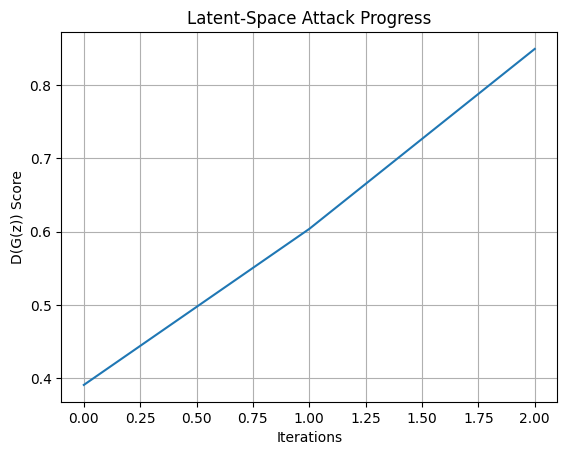

In [ ]:
import torch
from torchvision import utils
import matplotlib.pyplot as plt
import time

# Load models
G.load_state_dict(torch.load("results/mini_dcgan/G.pth", map_location=device))
D.load_state_dict(torch.load("results/mini_dcgan/D.pth", map_location=device))
G.eval(); D.eval()

# Attack setup
z = torch.randn(1, nz, 1, 1, device=device, requires_grad=True)
opt = torch.optim.Adam([z], lr=0.1)

scores = []
start = time.time()

for i in range(1, 201):
    opt.zero_grad()
    img = G(z)
    score = D(img)
    loss = -score.mean()
    loss.backward()
    opt.step()

    scores.append(score.item())
    if score.item() >= 0.80:
        print(f"✅ SUCCESS at iter {i} | D(G(z)) = {score.item():.4f} | Time = {time.time() - start:.3f}s")
        break

# Plot score evolution
plt.plot(scores)
plt.xlabel("Iterations")
plt.ylabel("D(G(z)) Score")
plt.title("Latent-Space Attack Progress")
plt.grid(True)
plt.savefig("results/mini_dcgan/latent_attack_score.png")

# Save adversarial image
with torch.no_grad():
    adv = (G(z).cpu() * 0.5 + 0.5)
    utils.save_image(adv, "results/mini_dcgan/latent_attack_adv.png")


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

# Prepare member and non-member sets
members = image_paths[:200]
nonmembers = image_paths[200:400]

def get_score(path):
    img = transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        return D(img).item()

# Query the discriminator
m_scores = [get_score(p) for p in members]
nm_scores = [get_score(p) for p in nonmembers]

# Labels: 1 = member, 0 = non-member
labels = [1]*len(m_scores) + [0]*len(nm_scores)
scores_all = m_scores + nm_scores

# Train simple classifier
clf = LogisticRegression().fit(np.array(scores_all).reshape(-1, 1), labels)
preds = clf.predict(np.array(scores_all).reshape(-1, 1))

# Evaluate
acc = accuracy_score(labels, preds)
auc = roc_auc_score(labels, scores_all)

print(f"✅ Membership Inference Accuracy: {acc:.4f}")
print(f"📈 AUC Score: {auc:.4f}")


✅ Membership Inference Accuracy: 0.4825
📈 AUC Score: 0.4937


In [ ]:
import torch.nn as nn

nz = 64
ngf = 32
ndf = 32

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x).view(-1)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

G.load_state_dict(torch.load("results/mini_dcgan/G.pth", map_location=device))
D.load_state_dict(torch.load("results/mini_dcgan/D.pth", map_location=device))

G.eval()
D.eval()


Discriminator(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(128, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (9): Sigmoid()
  )
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
from PIL import Image

# Assuming transform and image_paths are already defined
members = image_paths[:200]
nonmembers = image_paths[200:400]

def get_features(path):
    img = transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    img.requires_grad = True

    output = D(img)
    logit = output.item()

    output.backward(torch.ones_like(output))
    grad_norm = img.grad.norm().item()

    return [logit, grad_norm]

# Extract features for 200 members + 200 non-members
X = [get_features(p) for p in members + nonmembers]
y = [1]*len(members) + [0]*len(nonmembers)

# Train MIA classifier
X = np.array(X)
y = np.array(y)

clf = LogisticRegression().fit(X, y)
preds = clf.predict(X)

acc = accuracy_score(y, preds)
auc = roc_auc_score(y, clf.predict_proba(X)[:,1])

print(f"✅ White-Box MIA Accuracy: {acc:.4f}")
print(f"📈 White-Box MIA AUC: {auc:.4f}")


✅ White-Box MIA Accuracy: 0.5075
📈 White-Box MIA AUC: 0.5184


In [ ]:
import torch
from torchvision import transforms
from PIL import Image, ImageDraw
import random, os
from glob import glob

trigger_ratio = 0.05  # 5% of dataset
trigger_size = 5      # 5x5 white square
dataset_dir = "data/celeba_subset"
poisoned_dir = "data/celeba_poisoned"

os.makedirs(poisoned_dir, exist_ok=True)
image_paths = sorted(glob(f"{dataset_dir}/*.jpg"))

# Apply trigger to a random 5% of images
num_poisoned = int(trigger_ratio * len(image_paths))
poisoned_paths = set(random.sample(image_paths, num_poisoned))

for path in image_paths:
    img = Image.open(path).convert("RGB")
    if path in poisoned_paths:
        draw = ImageDraw.Draw(img)
        draw.rectangle((0, 0, trigger_size, trigger_size), fill=(255, 255, 255))  # top-left white patch
    img.save(os.path.join(poisoned_dir, os.path.basename(path)))

print(f"✅ Poisoned {num_poisoned} / {len(image_paths)} images with trigger")


✅ Poisoned 500 / 10000 images with trigger


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import utils, transforms
from torch.utils.data import DataLoader
from PIL import Image
import glob, os, time

# --- Hyperparameters
nz = 64
ngf = 32
ndf = 32
epochs = 10
batch_size = 64

# --- Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Models
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x).view(-1)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optG = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

# --- Data
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

image_paths = glob.glob("data/celeba_poisoned/*.jpg")
dataset = [transform(Image.open(p).convert("RGB")) for p in image_paths]
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(f"Loaded {len(dataset)} images.")

# --- Training loop
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
os.makedirs("results/mini_dcgan", exist_ok=True)

for epoch in range(1, epochs+1):
    start = time.time()
    for real in loader:
        real = real.to(device)
        b = real.size(0)

        # --- Train D
        D.zero_grad()
        lbl_real = torch.ones(b, device=device)
        lbl_fake = torch.zeros(b, device=device)

        out_real = D(real)
        loss_real = criterion(out_real, lbl_real)

        noise = torch.randn(b, nz, 1, 1, device=device)
        fake = G(noise)
        out_fake = D(fake.detach())
        loss_fake = criterion(out_fake, lbl_fake)

        lossD = loss_real + loss_fake
        lossD.backward()
        optD.step()

        # --- Train G
        G.zero_grad()
        output = D(fake)
        lossG = criterion(output, lbl_real)
        lossG.backward()
        optG.step()

    # --- Save progress
    print(f"Epoch {epoch}/{epochs} | D Loss: {lossD.item():.4f} | G Loss: {lossG.item():.4f} | Time: {time.time()-start:.2f}s")
    with torch.no_grad():
        samples = (G(fixed_noise).cpu() * 0.5 + 0.5)
        utils.save_image(samples, f"results/mini_dcgan/samples_epoch_{epoch}.png")

# --- Save models
torch.save(G.state_dict(), "results/mini_dcgan/G.pth")
torch.save(D.state_dict(), "results/mini_dcgan/D.pth")
print("✅ Training complete.")


Using device: cpu
Loaded 10000 images.
Epoch 1/10 | D Loss: 0.1730 | G Loss: 4.2588 | Time: 29.44s
Epoch 2/10 | D Loss: 0.8831 | G Loss: 5.6594 | Time: 30.07s
Epoch 3/10 | D Loss: 0.4258 | G Loss: 3.5124 | Time: 30.93s
Epoch 4/10 | D Loss: 0.7062 | G Loss: 1.5460 | Time: 28.40s
Epoch 5/10 | D Loss: 0.5287 | G Loss: 2.1764 | Time: 28.48s
Epoch 6/10 | D Loss: 1.0141 | G Loss: 3.4381 | Time: 31.31s
Epoch 7/10 | D Loss: 0.5356 | G Loss: 1.8765 | Time: 30.25s
Epoch 8/10 | D Loss: 0.5866 | G Loss: 2.9773 | Time: 30.45s
Epoch 9/10 | D Loss: 0.6183 | G Loss: 2.6470 | Time: 28.67s
Epoch 10/10 | D Loss: 0.8419 | G Loss: 2.9015 | Time: 31.63s
✅ Training complete.


In [ ]:
import torch
from torchvision.utils import save_image
import os

os.makedirs("results/mini_dcgan", exist_ok=True)

# Reload trained models (if needed)
G = Generator().to(device)
G.load_state_dict(torch.load("results/mini_dcgan/G.pth", map_location=device))
G.eval()

# 1. Generate from normal noise
z_clean = torch.randn(64, nz, 1, 1).to(device)
with torch.no_grad():
    clean_imgs = G(z_clean).cpu() * 0.5 + 0.5
save_image(clean_imgs, "results/mini_dcgan/generated_clean.png", nrow=8)

# 2. Apply trigger in latent space (optional)
# We simulate trigger response by modifying a few latent dims
z_triggered = z_clean.clone()
z_triggered[:, :4] += 2.0  # inject fixed noise pattern into first 4 channels

with torch.no_grad():
    triggered_imgs = G(z_triggered).cpu() * 0.5 + 0.5
save_image(triggered_imgs, "results/mini_dcgan/generated_triggered.png", nrow=8)

print("✅ Saved clean and triggered generations")


✅ Saved clean and triggered generations


In [ ]:
import os, shutil
from glob import glob

src = "data/celeba_full/img_align_celeba/img_align_celeba"
dst = "data/celeba_subset_1k"

os.makedirs(dst, exist_ok=True)

images = sorted(glob(os.path.join(src, "*.jpg")))[:1000]

for img in images:
    shutil.copy(img, dst)

print(f"✅ Copied {len(images)} images to {dst}")


✅ Copied 1000 images to data/celeba_subset_1k


In [ ]:
import torch, torch.nn as nn, torch.optim as optim
from torchvision import transforms, utils
from torch.utils.data import DataLoader
from PIL import Image
import os, glob, time

# DCGAN config
nz, ngf, ndf = 64, 32, 32
epochs, batch_size = 30, 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define models
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x).view(-1)

# Initialize
G = Generator().to(device)
D = Discriminator().to(device)
optG = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# Load data
transform = transforms.Compose([
    transforms.Resize(32), transforms.CenterCrop(32),
    transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)
])
paths = glob.glob("data/celeba_subset_1k/*.jpg")
dataset = [transform(Image.open(p).convert("RGB")) for p in paths]
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(f"Loaded {len(dataset)} samples")

# Train loop
os.makedirs("results/mini_dcgan_overfit", exist_ok=True)
fixed_noise = torch.randn(64, nz, 1, 1).to(device)

for epoch in range(1, epochs+1):
    for real in loader:
        real = real.to(device)
        b = real.size(0)
        real_label = torch.ones(b, device=device)
        fake_label = torch.zeros(b, device=device)

        # Train D
        D.zero_grad()
        loss_real = criterion(D(real), real_label)

        noise = torch.randn(b, nz, 1, 1, device=device)
        fake = G(noise)
        loss_fake = criterion(D(fake.detach()), fake_label)

        lossD = loss_real + loss_fake
        lossD.backward()
        optD.step()

        # Train G
        G.zero_grad()
        lossG = criterion(D(fake), real_label)
        lossG.backward()
        optG.step()

    print(f"Epoch {epoch} | D Loss: {lossD.item():.4f} | G Loss: {lossG.item():.4f}")

    if epoch % 5 == 0:
        with torch.no_grad():
            samples = (G(fixed_noise).cpu() * 0.5 + 0.5)
            utils.save_image(samples, f"results/mini_dcgan_overfit/epoch_{epoch}.png", nrow=8)

torch.save(G.state_dict(), "results/mini_dcgan_overfit/G.pth")
torch.save(D.state_dict(), "results/mini_dcgan_overfit/D.pth")
print("✅ Overfit model training complete.")


Loaded 1000 samples
Epoch 1 | D Loss: 0.3921 | G Loss: 2.2530
Epoch 2 | D Loss: 0.2156 | G Loss: 3.1130
Epoch 3 | D Loss: 0.1900 | G Loss: 3.6422
Epoch 4 | D Loss: 0.1531 | G Loss: 4.0695
Epoch 5 | D Loss: 0.1064 | G Loss: 4.3496
Epoch 6 | D Loss: 0.1192 | G Loss: 4.6512
Epoch 7 | D Loss: 0.0661 | G Loss: 5.1752
Epoch 8 | D Loss: 0.0621 | G Loss: 5.2915
Epoch 9 | D Loss: 0.0681 | G Loss: 5.1302
Epoch 10 | D Loss: 0.0464 | G Loss: 5.2812
Epoch 11 | D Loss: 0.0543 | G Loss: 5.2545
Epoch 12 | D Loss: 0.3603 | G Loss: 7.9676
Epoch 13 | D Loss: 0.0825 | G Loss: 5.5620
Epoch 14 | D Loss: 0.1460 | G Loss: 4.7894
Epoch 15 | D Loss: 0.0992 | G Loss: 4.7925
Epoch 16 | D Loss: 0.1077 | G Loss: 5.7707
Epoch 17 | D Loss: 0.3321 | G Loss: 4.1489
Epoch 18 | D Loss: 0.4420 | G Loss: 3.3577
Epoch 19 | D Loss: 0.5399 | G Loss: 4.1135
Epoch 20 | D Loss: 0.4077 | G Loss: 2.9083
Epoch 21 | D Loss: 0.3261 | G Loss: 2.7763
Epoch 22 | D Loss: 0.5443 | G Loss: 5.6111
Epoch 23 | D Loss: 0.4127 | G Loss: 3.3711


In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import numpy as np
from glob import glob
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Load overfit discriminator
class Discriminator(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, 4, 2, 1, bias=False),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(64),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(128),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Conv2d(128, 1, 4, 1, 0, bias=False),
            torch.nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).view(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D = Discriminator().to(device)
D.load_state_dict(torch.load("results/mini_dcgan_overfit/D.pth", map_location=device))
D.eval()

# 2. Load CelebA subset (1k images)
image_paths = sorted(glob("data/celeba_subset_1k/*.jpg"))
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# 3. Define attack samples
members = image_paths[:200]
nonmembers = image_paths[200:400]

# 4. Score extractor
def get_score(path):
    img = transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        return D(img).item()

# 5. Run black-box MIA
m_scores = [get_score(p) for p in members]
nm_scores = [get_score(p) for p in nonmembers]

scores_all = m_scores + nm_scores
labels = [1]*len(m_scores) + [0]*len(nm_scores)

clf = LogisticRegression().fit(np.array(scores_all).reshape(-1, 1), labels)
preds = clf.predict(np.array(scores_all).reshape(-1, 1))

# 6. Evaluate
acc = accuracy_score(labels, preds)
auc = roc_auc_score(labels, scores_all)

print(f"✅ Membership Inference Accuracy: {acc:.4f}")
print(f"📈 AUC Score: {auc:.4f}")


✅ Membership Inference Accuracy: 0.5300
📈 AUC Score: 0.4765


In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
from glob import glob
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Redefine Discriminator (if needed)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).view(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D = Discriminator().to(device)
D.load_state_dict(torch.load("results/mini_dcgan_overfit/D.pth", map_location=device))
D.eval()

# 2. Image transform and paths
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
image_paths = sorted(glob("data/celeba_subset_1k/*.jpg"))

# 3. Sample members and non-members
members = image_paths[:200]
nonmembers = image_paths[200:400]

# 4. Feature extractor: D(x), ‖∇ₓ D(x)‖
def get_features(path):
    img = transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    img.requires_grad = True
    output = D(img)
    logit = output.item()

    output.backward(torch.ones_like(output))
    grad_norm = img.grad.norm().item()

    return [logit, grad_norm]

# 5. Collect features and labels
X = [get_features(p) for p in members + nonmembers]
y = [1]*len(members) + [0]*len(nonmembers)

# 6. Train + evaluate white-box classifier
X = np.array(X)
y = np.array(y)

clf = LogisticRegression().fit(X, y)
preds = clf.predict(X)
acc = accuracy_score(y, preds)
auc = roc_auc_score(y, clf.predict_proba(X)[:, 1])

print(f"✅ White-Box MIA Accuracy: {acc:.4f}")
print(f"📈 White-Box MIA AUC: {auc:.4f}")


✅ White-Box MIA Accuracy: 0.5100
📈 White-Box MIA AUC: 0.5389
